# 🚀 Image Denoising using Convolutional Autoencoder (BSD500)

This project demonstrates image denoising using a deep Convolutional Autoencoder built with TensorFlow/Keras.

In [ ]:
# Step 1: Extract Dataset
import zipfile

with zipfile.ZipFile('bsd500.zip', 'r') as zip_ref:
    zip_ref.extractall('bsd500')

print('Dataset extracted successfully!')

Dataset extracted successfully!


In [ ]:
print(os.listdir("bsd500"))

['images', 'ground_truth']


In [ ]:
print(os.listdir("bsd500/images/train")[:10])

['374067.jpg', '45077.jpg', '246016.jpg', '323016.jpg', '159091.jpg', '227046.jpg', '42078.jpg', '231015.jpg', '246053.jpg', '59078.jpg']


In [ ]:
import os
import cv2
import numpy as np

data_path = "bsd500/images/train"

images = []

for file in os.listdir(data_path):
    if file.lower().endswith(".jpg"):
        img_path = os.path.join(data_path, file)
        img = cv2.imread(img_path)

        if img is None:
            print("Failed:", img_path)
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (128, 128))
        img = img / 255.0
        images.append(img)

images = np.array(images)

print("Total images loaded:", len(images))
print("Shape:", images.shape)

Total images loaded: 200
Shape: (200, 128, 128, 3)


(Number_of_Images, Height, Width, Channels)

In [ ]:
# Step 3: Add Gaussian Noise
noise_factor = 0.1

noisy_images = images + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=images.shape
)

noisy_images = np.clip(noisy_images, 0., 1.)
print('Noise added!')

Noise added!


| noise_factor | Effect                 |
| ------------ | ---------------------- |
| 0.05         | Light noise            |
| 0.1          | Good for training      |
| 0.2          | Harder training        |
| 0.3          | Very noisy             |
| 0.5          | Almost corrupted image |


In [ ]:
# Step 4: Build Convolutional Autoencoder
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

input_img = Input(shape=(128, 128, 3))

# Encoder
x = Conv2D(64, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(256, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(256, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 3)    │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,331,459 (5.08 MB)

 Trainable params: 1,331,459 (5.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Step 5: Train Model
autoencoder.fit(
    noisy_images,
    images,
    epochs=20,
    batch_size=16,
    validation_split=0.1
)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 45s 4s/step - loss: 0.0583 - val_loss: 0.0615
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 43s 4s/step - loss: 0.0406 - val_loss: 0.0322
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 43s 4s/step - loss: 0.0293 - val_loss: 0.0220
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 49s 4s/step - loss: 0.0226 - val_loss: 0.0173
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 74s 3s/step - loss: 0.0187 - val_loss: 0.0201
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - loss: 0.0173 - val_loss: 0.0149
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 43s 4s/step - loss: 0.0160 - val_loss: 0.0144
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 83s 4s/step - loss: 0.0148 - val_loss: 0.0138
Epoch 9/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step - loss: 0.0137 - val_loss: 0.0130
Epoch 10/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - loss: 0.0134 - val_loss: 0.0126
Epoch 11/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 82s 4s/step - loss: 0.0125 - val_loss: 0.0127
Epoch 12/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 81s 4s/step - loss: 0.0123 - val_lo

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 609ms/step


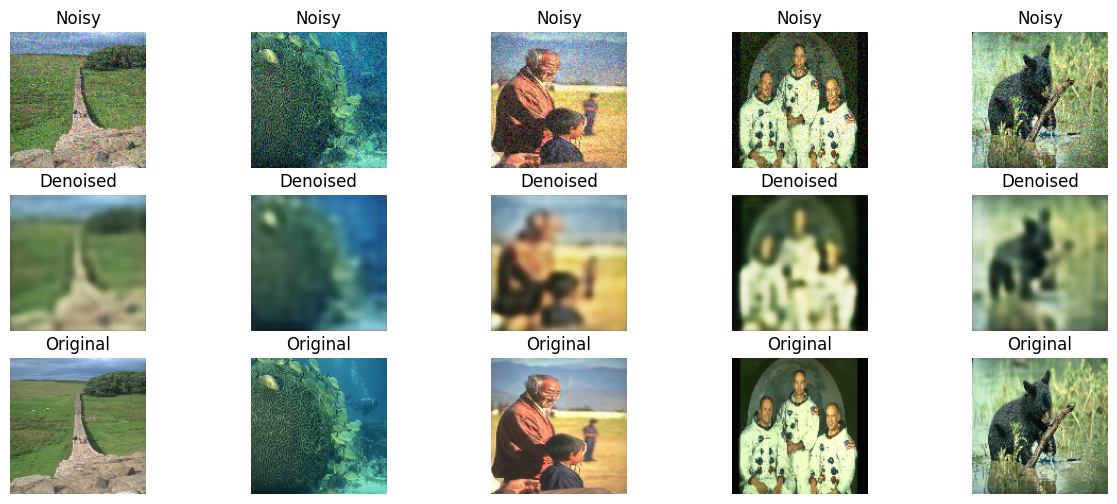

In [ ]:
# Step 6: Visualize Results
import matplotlib.pyplot as plt

decoded_imgs = autoencoder.predict(noisy_images[:5])

plt.figure(figsize=(15,6))

for i in range(5):

    # Noisy
    ax = plt.subplot(3, 5, i+1)
    plt.imshow(noisy_images[i])
    plt.title('Noisy')
    plt.axis('off')

    # Denoised
    ax = plt.subplot(3, 5, i+6)
    plt.imshow(decoded_imgs[i])
    plt.title('Denoised')
    plt.axis('off')

    # Original
    ax = plt.subplot(3, 5, i+11)
    plt.imshow(images[i])
    plt.title('Original')
    plt.axis('off')

plt.show()

In [ ]:
# Step 7: Evaluate with PSNR
import tensorflow as tf

psnr = tf.image.psnr(decoded_imgs, images[:5], max_val=1.0)
print('PSNR values:', psnr.numpy())

PSNR values: [23.334106 21.81701  20.714624 18.29202  19.44642 ]


Higher PSNR = better reconstruction.

PSNR Full Form

PSNR = Peak Signal-to-Noise Ratio

It is a measurement used to evaluate image quality, especially in:

Image denoising

Image compression

Super-resolution

Image reconstruction

| PSNR (dB)  | Quality Level                |
| ---------- | ---------------------------- |
| < 15 dB    | Very Poor                    |
| 15 – 20 dB | Acceptable                   |
| 20 – 25 dB | Good                         |
| 25 – 30 dB | Very Good                    |
| 30+ dB     | Excellent (almost identical) |


If You Want to Upgrade Further

Next-level improvements:

Replace autoencoder with UNet

Try Salt & Pepper noise

Add SSIM metric

Compare shallow vs deep model

Implement DnCNN (research paper model)

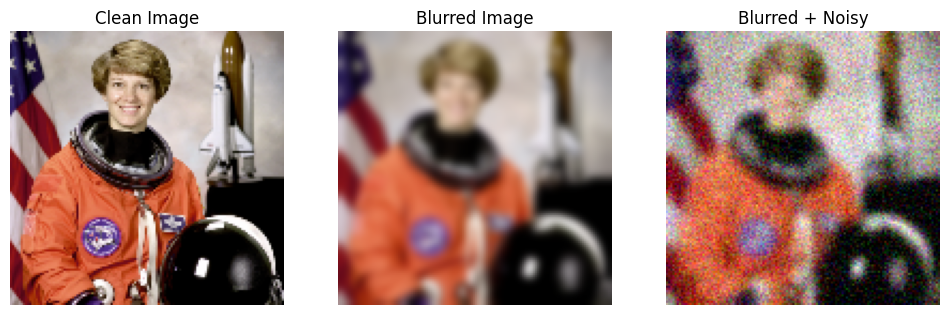

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import data

# 1️⃣ Load a sample clean image
img = data.astronaut()   # built-in sample image
img = cv2.resize(img, (128, 128))

# 2️⃣ Apply Gaussian Blur
blurred = cv2.GaussianBlur(img, (11, 11), 0)

# 3️⃣ Add Gaussian Noise
noise = np.random.normal(0, 25, blurred.shape)
noisy_blurred = blurred + noise
noisy_blurred = np.clip(noisy_blurred, 0, 255).astype(np.uint8)

# 4️⃣ Save image
cv2.imwrite("synthetic_blurred_noisy.jpg",
            cv2.cvtColor(noisy_blurred, cv2.COLOR_RGB2BGR))

# 5️⃣ Show results
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Clean Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(blurred)
plt.title("Blurred Image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(noisy_blurred)
plt.title("Blurred + Noisy")
plt.axis("off")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step


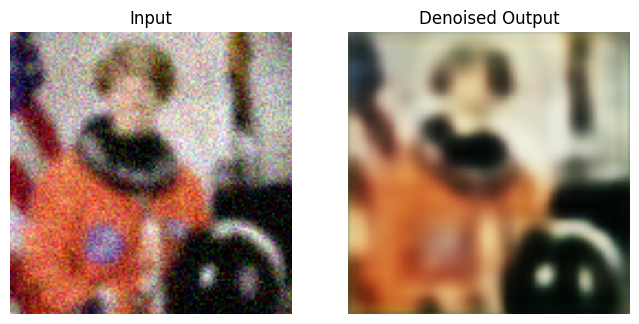

In [ ]:
# Normalize
test_img = noisy_blurred / 255.0
test_img = np.expand_dims(test_img, axis=0)

# Predict
denoised = autoencoder.predict(test_img)[0]

# Show result
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(noisy_blurred)
plt.title("Input")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(denoised)
plt.title("Denoised Output")
plt.axis("off")

plt.show()

In [ ]:
import tensorflow as tf

clean = img / 255.0
psnr = tf.image.psnr(clean, denoised, max_val=1.0)
print("PSNR:", psnr.numpy())

PSNR: 16.550224
